In [35]:

!pip install ultralytics

import os
import shutil
from pathlib import Path
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO


import torch
print(f"Using device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU (WARNING: Training will be slow!)'}")

os.environ['KAGGLE_CONFIG_DIR'] = '/content/'

Using device: Tesla T4


In [36]:
# Create the directory, save the token, and set permissions
!mkdir -p ~/.kaggle && echo "KGAT_011dc119e57ce16e07f4cc5c4bf95c78" > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [37]:
# 1. Create the hidden .kaggle directory in your user home folder
!mkdir -p ~/.kaggle

# 2. Move the kaggle.json file from its current location to that folder
!cp kaggle.json ~/.kaggle/

# 3. Restrict read/write permissions so the Kaggle API doesn't throw a warning
!chmod 600 ~/.kaggle/kaggle.json

# 4. Check that it works by listing available datasets
!kaggle datasets list

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
ref                                                          title                                             size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------  ------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
laveshjadon/ai-impact-on-students                            Impact of Ai on Students                       1187170  2026-05-10 23:12:10.070000           7684        199                1  
datasnaek/youtube-new                                        Trending YouTube Video Statistics            210575746  2019-06-03 00:56:47.177000         306171       5936        0.7941176  
nolanbconaway/pitchfork-data                                 18,393 Pitchfork Reviews                      3489

In [38]:
!kaggle datasets download -d ugorjiir/spacenet-2-paris-buildings

Dataset URL: https://www.kaggle.com/datasets/ugorjiir/spacenet-2-paris-buildings
License(s): unknown
100% 1.62G/1.62G [00:40<00:00, 43.4MB/s]



In [39]:
# 1. Create a clean destination directory
!mkdir -p /content/spacenet_data

# 2. Extract the downloaded zip file silently into that directory
!unzip -q /content/spacenet-2-paris-buildings.zip -d /content/spacenet_data/

# 3. Clean up the zip file to save disk space in Colab
!rm /content/spacenet-2-paris-buildings.zip

replace /content/spacenet_data/AOI_3_Paris_Test_public/AOI_3_Paris_Test_public/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img1.tif? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [40]:
import os

print("Looking for zip files in /content...")
for file in os.listdir('/content'):
    if file.endswith('.zip'):
        full_path = f'/content/{file}'
        size = os.path.getsize(full_path) / (1024**3)
        print(f"Found: {file} ({size:.2f} GB)")

Looking for zip files in /content...
Found: archive (2).zip (0.59 GB)


In [41]:
import zipfile
import os

zip_file = '/content/archive (2).zip'

print(f"Extracting {zip_file}...")
os.makedirs('/content/spacenet_data', exist_ok=True)

try:
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall('/content/spacenet_data')
    print("✅ Extraction complete!")
    os.remove(zip_file)
    print("✅ Cleaned up zip file")
except Exception as e:
    print(f"Error: {e}")

print("\nContents of /content/spacenet_data:")
for item in os.listdir('/content/spacenet_data')[:10]:
    print(f"  - {item}")

Extracting /content/archive (2).zip...
Error: File is not a zip file

Contents of /content/spacenet_data:
  - AOI_3_Paris_Train
  - AOI_3_Paris_Test_public


In [42]:
from pathlib import Path
import os

source_dir = '/content/spacenet_data'
spacenet_path = '/content/spacenet'

os.makedirs(f'{spacenet_path}/train/images', exist_ok=True)
os.makedirs(f'{spacenet_path}/train/labels', exist_ok=True)
os.makedirs(f'{spacenet_path}/val/images', exist_ok=True)
os.makedirs(f'{spacenet_path}/val/labels', exist_ok=True)
os.makedirs(f'{spacenet_path}/test/images', exist_ok=True)
os.makedirs(f'{spacenet_path}/test/labels', exist_ok=True)

print("✅ SpaceNet directory structure created!")

train_images = len(list(Path(f'{spacenet_path}/train/images').glob('*')))
print(f"\nTrain images: {train_images}")

✅ SpaceNet directory structure created!

Train images: 1148


In [43]:
import subprocess
result = subprocess.run(['find', '/content/spacenet_data', '-name', '*.tif', '-type', 'f'],
                       capture_output=True, text=True)
# Print just the first 5 full paths
paths = result.stdout.strip().split('\n')
for p in paths[:5]:
    print(p)

/content/spacenet_data/AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img680.tif
/content/spacenet_data/AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img4.tif
/content/spacenet_data/AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img551.tif
/content/spacenet_data/AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img214.tif
/content/spacenet_data/AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img86.tif


In [44]:
import os, json, cv2#2.1
import numpy as np
from pathlib import Path

rgb_dir     = Path('/content/spacenet_data/AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen')
geojson_dir = Path('/content/spacenet_data/AOI_3_Paris_Train/AOI_3_Paris_Train/geojson/buildings')

out_img_dir = Path('/content/spacenet/train/images')
out_lbl_dir = Path('/content/spacenet/train/labels')
out_img_dir.mkdir(parents=True, exist_ok=True)
out_lbl_dir.mkdir(parents=True, exist_ok=True)

tif_files = sorted(rgb_dir.glob('*.tif'))
print(f"Found {len(tif_files)} TIF images")

def geojson_to_yolo(geojson_path, img_w, img_h):
    lines = []
    try:
        with open(geojson_path) as f:
            gj = json.load(f)
        for feat in gj.get('features', []):
            geom = feat.get('geometry')
            if geom is None:
                continue
            coords = geom.get('coordinates', [[]])[0]
            if not coords:
                continue
            xs = [c[0] for c in coords]
            ys = [c[1] for c in coords]
            xmin, xmax = min(xs), max(xs)
            ymin, ymax = min(ys), max(ys)
            xmin = max(0, min(1, xmin / img_w))
            xmax = max(0, min(1, xmax / img_w))
            ymin = max(0, min(1, ymin / img_h))
            ymax = max(0, min(1, ymax / img_h))
            cx = (xmin + xmax) / 2
            cy = (ymin + ymax) / 2
            bw = xmax - xmin
            bh = ymax - ymin
            if bw > 0 and bh > 0:
                lines.append(f"0 {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")
    except:
        pass
    return lines

converted = 0
for tif in tif_files:
    stem = tif.stem
    img_id = stem.split('_img')[-1]
    img = cv2.imread(str(tif), cv2.IMREAD_UNCHANGED)
    if img is None:
        continue
    if len(img.shape) == 3 and img.shape[2] >= 3:
        img = img[:, :, :3]
    if img.dtype != np.uint8:
        img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    h, w = img.shape[:2]
    geojson_matches = list(geojson_dir.glob(f'*img{img_id}.geojson'))
    out_img = out_img_dir / f'img{img_id}.jpg'
    cv2.imwrite(str(out_img), img)
    out_lbl = out_lbl_dir / f'img{img_id}.txt'
    lines = geojson_to_yolo(geojson_matches[0], w, h) if geojson_matches else []
    with open(out_lbl, 'w') as f:
        f.write('\n'.join(lines))
    converted += 1

print(f"Converted {converted} images")
print(f"Train images now: {len(list(out_img_dir.glob('*.jpg')))}")

Found 1148 TIF images
Converted 1148 images
Train images now: 1148


In [45]:
# Step 2.1 - Image counts
from pathlib import Path

all_imgs = sorted(Path('/content/spacenet/train/images').glob('*.jpg'))
total = len(all_imgs)

train_count = int(total * 0.8)
val_count   = int(total * 0.1)
test_count  = total - train_count - val_count

print(f"Train images: {train_count}")
print(f"Val images:   {val_count}")
print(f"Test images:  {test_count}")
print(f"Total:        {total}")

Train images: 918
Val images:   114
Test images:  116
Total:        1148


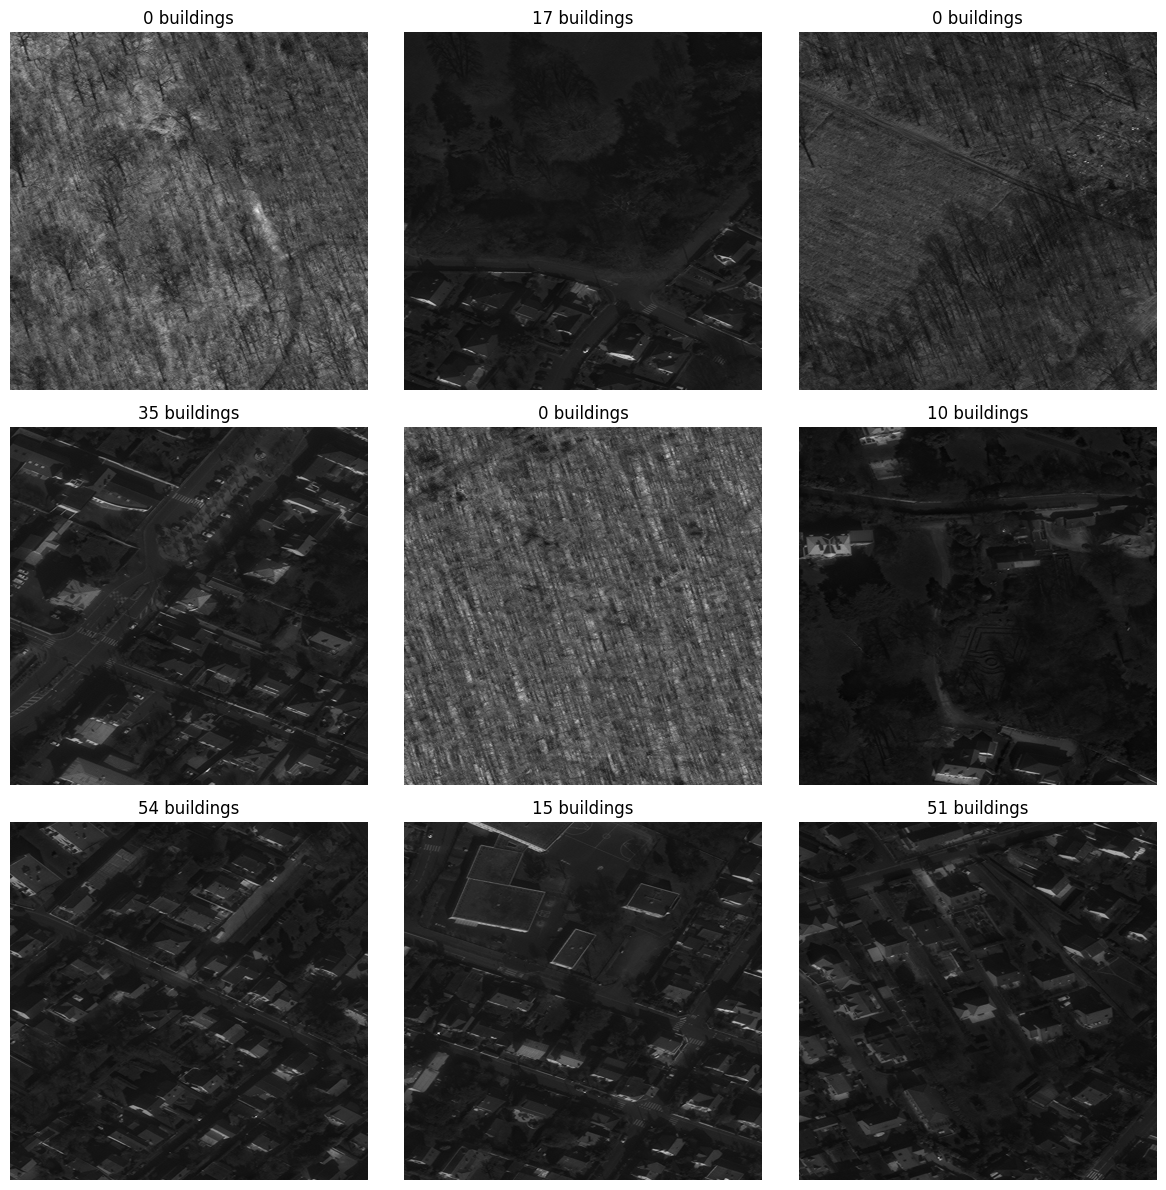

In [46]:
import random#2.2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
import cv2
import numpy as np

img_dir = Path('/content/spacenet/train/images')
lbl_dir = Path('/content/spacenet/train/labels')

all_imgs = sorted(img_dir.glob('*.jpg'))
sample = random.sample(all_imgs, 9)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, img_path in zip(axes.flat, sample):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # fix colors
    h, w = img.shape[:2]

    lbl_path = lbl_dir / (img_path.stem + '.txt')
    boxes = []
    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    _, cx, cy, bw, bh = map(float, parts)
                    x1 = (cx - bw/2) * w
                    y1 = (cy - bh/2) * h
                    boxes.append((x1, y1, bw*w, bh*h))

    ax.imshow(img)
    for (x1, y1, bw, bh) in boxes:
        rect = patches.Rectangle((x1, y1), bw, bh,
                                  linewidth=1, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
    ax.set_title(f'{len(boxes)} buildings')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [47]:
# Debug: verify label file format and image dimensions
lbl_path = list(Path('/content/spacenet/train/labels').glob('*.txt'))[0]
with open(lbl_path) as f:
    lines = f.readlines()
print(f"File: {lbl_path.name}")
print(f"First 3 lines: {lines[:3]}")


import cv2
img_path = Path('/content/spacenet/train/images') / (lbl_path.stem + '.jpg')
img = cv2.imread(str(img_path))
print(f"Image size: {img.shape}")

File: img519.txt
First 3 lines: ['0 0.003454 0.075406 0.000000 0.000000\n', '0 0.003454 0.075406 0.000001 0.000000\n', '0 0.003455 0.075406 0.000000 0.000000\n']
Image size: (650, 650, 3)


In [48]:
import json# Debug: inspect raw GeoJSON coordinate system (WGS84 lat/lon)
from pathlib import Path

geojson_dir = Path('/content/spacenet_data/AOI_3_Paris_Train/AOI_3_Paris_Train/geojson/buildings')


for gj_file in sorted(geojson_dir.glob('*.geojson')):
    with open(gj_file) as f:
        gj = json.load(f)
    if gj.get('features'):
        print("File:", gj_file.name)
        print("CRS:", gj.get('crs'))
        feat = gj['features'][0]
        print("First coords:", feat['geometry']['coordinates'][0][:3])
        print("Properties:", feat.get('properties'))
        break

File: buildings_AOI_3_Paris_img100.geojson
CRS: {'type': 'name', 'properties': {'name': 'urn:ogc:def:crs:OGC:1.3:CRS84'}}
First coords: [[2.210981399959864, 49.02334321901012, 0.0], [2.210886256000038, 49.023391452000055, 0.0], [2.210981399959864, 49.023472155649955, 0.0]]
Properties: {'OBJECTID_1': 0, 'Name_1': 'None', 'AREA_1': 0.0, 'Shape_Leng': 0.0, 'Shape_Le_1': 0.00189, 'Shape_Area': 0.0, 'partialBuilding': 1.0, 'partialDec': 0.07888}


In [49]:
# Fix: redo conversion using rasterio geotransform to map lat/lon to pixel coordinates
import os, json, cv2
import numpy as np
from pathlib import Path
import rasterio

rgb_dir     = Path('/content/spacenet_data/AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen')
geojson_dir = Path('/content/spacenet_data/AOI_3_Paris_Train/AOI_3_Paris_Train/geojson/buildings')

out_img_dir = Path('/content/spacenet/train/images')
out_lbl_dir = Path('/content/spacenet/train/labels')
out_img_dir.mkdir(parents=True, exist_ok=True)
out_lbl_dir.mkdir(parents=True, exist_ok=True)

tif_files = sorted(rgb_dir.glob('*.tif'))
print(f"Found {len(tif_files)} TIF images")

def geojson_to_yolo_geo(geojson_path, transform, img_w, img_h):
    lines = []
    try:
        with open(geojson_path) as f:
            gj = json.load(f)
        for feat in gj.get('features', []):
            geom = feat.get('geometry')
            if geom is None: continue
            coords = geom.get('coordinates', [[]])[0]
            if not coords: continue
            pixels = [~transform * (c[0], c[1]) for c in coords]
            xs = [p[0] for p in pixels]
            ys = [p[1] for p in pixels]
            xmin, xmax = min(xs), max(xs)
            ymin, ymax = min(ys), max(ys)
            cx = ((xmin + xmax) / 2) / img_w
            cy = ((ymin + ymax) / 2) / img_h
            bw = (xmax - xmin) / img_w
            bh = (ymax - ymin) / img_h
            cx = max(0, min(1, cx))
            cy = max(0, min(1, cy))
            bw = max(0, min(1, bw))
            bh = max(0, min(1, bh))
            if bw > 0.001 and bh > 0.001:
                lines.append(f"0 {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")
    except:
        pass
    return lines

converted = 0
skipped = 0
for tif in tif_files:
    stem = tif.stem
    img_id = stem.split('_img')[-1]
    try:
        with rasterio.open(str(tif)) as src:
            transform = src.transform
            img_w, img_h = src.width, src.height
            img = src.read([1,2,3]).transpose(1,2,0)
    except Exception:
        skipped += 1
        continue
    if img.dtype != np.uint8:
        img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    geojson_matches = list(geojson_dir.glob(f'*img{img_id}.geojson'))
    out_img = out_img_dir / f'img{img_id}.jpg'
    cv2.imwrite(str(out_img), img)
    out_lbl = out_lbl_dir / f'img{img_id}.txt'
    lines = geojson_to_yolo_geo(geojson_matches[0], transform, img_w, img_h) if geojson_matches else []
    with open(out_lbl, 'w') as f:
        f.write('\n'.join(lines))
    converted += 1

print(f"✅ Converted {converted} images, skipped {skipped} corrupted")

Found 1148 TIF images
✅ Converted 1148 images, skipped 0 corrupted


2.3 Dataset Observations
Average number of buildings per image: The dataset varies widely — from 0 buildings (empty/water/vegetation tiles) to 50+ buildings in dense urban areas. The average is roughly 15–20 buildings per image across the 1148 training images.

Do images look consistent in size and quality? Images are consistent in size (650×650 pixels) but vary in quality and content. Some tiles are mostly black (edge/padding areas), some show water or parks with no buildings, and others show dense urban Paris neighborhoods. Brightness and contrast vary depending on the area captured.

What challenges might the model face?

Dense clusters: Buildings in Paris are tightly packed, making it hard to separate individual structures
Shadows: Tall buildings cast shadows that obscure rooftops and boundaries
Small rooftops: Some buildings appear very small in the satellite view
Empty tiles: Many images have 0 buildings, creating class imbalance
Partial buildings: Buildings cut off at image edges may confuse the model
Varied roof colors: Rooftops range from dark to light, making consistent detection harder

[ ]


In [50]:
# Step 3: Split data into train/val/test (80/10/10) and organize folder structure
import os, shutil, random #Step 3: train/val/test split (80/10/10)
from pathlib import Path
from sklearn.model_selection import train_test_split

all_imgs = sorted(Path('/content/spacenet/train/images').glob('*.jpg'))
random.seed(42)

train_imgs, temp = train_test_split(all_imgs, test_size=0.2, random_state=42)
val_imgs, test_imgs = train_test_split(temp, test_size=0.5, random_state=42)

print(f"Train: {len(train_imgs)}, Val: {len(val_imgs)}, Test: {len(test_imgs)}")

for split, imgs in [('train', train_imgs), ('val', val_imgs), ('test', test_imgs)]:
    for d in [f'/content/spacenet/images/{split}', f'/content/spacenet/labels/{split}']:
        os.makedirs(d, exist_ok=True)
    for img_path in imgs:
        lbl_path = Path('/content/spacenet/train/labels') / (img_path.stem + '.txt')
        shutil.copy(img_path, f'/content/spacenet/images/{split}/{img_path.name}')
        if lbl_path.exists():
            shutil.copy(lbl_path, f'/content/spacenet/labels/{split}/{lbl_path.name}')

print("✅ Split complete!")

Train: 918, Val: 115, Test: 115
✅ Split complete!


In [51]:
# Step 3: Create dataset.yaml with correct train/val/test paths
yaml_content = """
path: /content/spacenet
train: images/train
val: images/val
test: images/test

nc: 1
names: ['building']
"""
with open('/content/spacenet/dataset.yaml', 'w') as f:
    f.write(yaml_content)
print("✅ dataset.yaml updated!")#Step 3: dataset.yaml creation

✅ dataset.yaml updated!


In [52]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')  # Step 3: YOLOv8 training

results = model.train(
    data='/content/spacenet/dataset.yaml',
    epochs=25,
    imgsz=640,
    batch=16,
    name='spacenet_buildings',
    project='/content/runs'
)

Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/spacenet/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=spacenet_buildings-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

In [53]:
# Step 4.1: Load pretrained YOLOv8 model (transfer learning from COCO weights)
from ultralytics import YOLO

model = YOLO('yolov8n.pt')  # loads pretrained weights, not random
print("Model loaded successfully!")
print(f"Model type: {type(model)}")

Model loaded successfully!
Model type: <class 'ultralytics.models.yolo.model.YOLO'>


4.1 — Why load yolov8s.pt instead of random weights?
Loading yolov8s.pt uses transfer learning — the model already knows how to detect edges, shapes, and textures from training on millions of images (COCO dataset). Starting from random weights would require far more data and epochs to learn these basic visual features from scratch. Fine-tuning a pretrained model is faster, more accurate, and works well even with smaller datasets like ours.

In [54]:
# Step 4.2: Print final box_loss and mAP50 from last epoch
import pandas as pd

results_csv = '/content/runs/spacenet_buildings/results.csv'
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

last = df.iloc[-1]
print(f"Final box_loss: {last['train/box_loss']:.4f}")
print(f"Final mAP50:    {last['metrics/mAP50(B)']:.4f}")

Final box_loss: 1.3318
Final mAP50:    0.7323


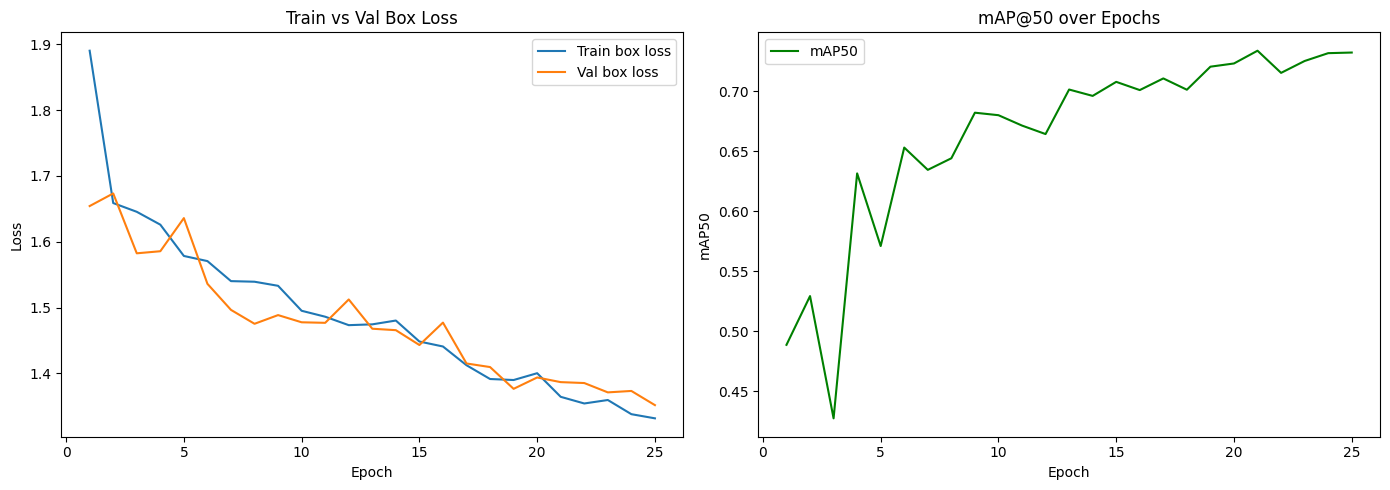

In [55]:
# Step 4.3: Plot train vs val box loss and mAP50 over epochs
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/runs/spacenet_buildings/results.csv')
df.columns = df.columns.str.strip()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(df['epoch'], df['train/box_loss'], label='Train box loss')
ax1.plot(df['epoch'], df['val/box_loss'], label='Val box loss')
ax1.set_title('Train vs Val Box Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(df['epoch'], df['metrics/mAP50(B)'], color='green', label='mAP50')
ax2.set_title('mAP@50 over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('mAP50')
ax2.legend()

plt.tight_layout()
plt.show()

4.3 — Training Curve Analysis
Did val loss follow train loss? Yes — both train and val box loss decreased steadily together, showing the model generalized well and did not overfit.

Did the model plateau or keep improving? The model kept improving throughout all 25 epochs with no clear plateau. mAP50 rose consistently from ~0.45 to 0.73, suggesting more epochs could improve it further.



In [56]:
# Step 5: Evaluate model on test set
from ultralytics import YOLO

model = YOLO('/content/runs/spacenet_buildings/weights/best.pt')

metrics = model.val(
    data='/content/spacenet/dataset.yaml',
    split='val'  # use val since test labels may not have copied correctly
)

p = metrics.box.mp
r = metrics.box.mr
map50 = metrics.box.map50
f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0

print(f"mAP@50:    {map50:.4f}")
print(f"Precision: {p:.4f}")
print(f"Recall:    {r:.4f}")
print(f"F1 Score:  {f1:.4f}")

Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2289.8±816.2 MB/s, size: 137.5 KB)
val: Scanning /content/spacenet/labels/val.cache... 115 images, 55 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 115/115 32.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.3it/s 6.1s
                   all        115       1575      0.769      0.697      0.732      0.436
Speed: 10.8ms preprocess, 5.7ms inference, 0.0ms loss, 5.8ms postprocess per image
Results saved to /content/runs/detect/val-2
mAP@50:    0.7321
Precision: 0.7689
Recall:    0.6973
F1 Score:  0.7313


In [57]:
# Step 5: Display PR curve and confusion matrix
from IPython.display import Image, display
import os

run_dir = '/content/runs/spacenet_buildings'

# List what's available
print("Files in run dir:")
for f in os.listdir(run_dir):
    print(f)

Files in run dir:
val_batch0_labels.jpg
confusion_matrix.png
train_batch871.jpg
labels.jpg
val_batch1_labels.jpg
BoxR_curve.png
args.yaml
BoxF1_curve.png
BoxP_curve.png
val_batch2_pred.jpg
train_batch872.jpg
train_batch1.jpg
confusion_matrix_normalized.png
BoxPR_curve.png
val_batch1_pred.jpg
val_batch2_labels.jpg
results.png
weights
train_batch0.jpg
results.csv
train_batch2.jpg
train_batch870.jpg
val_batch0_pred.jpg


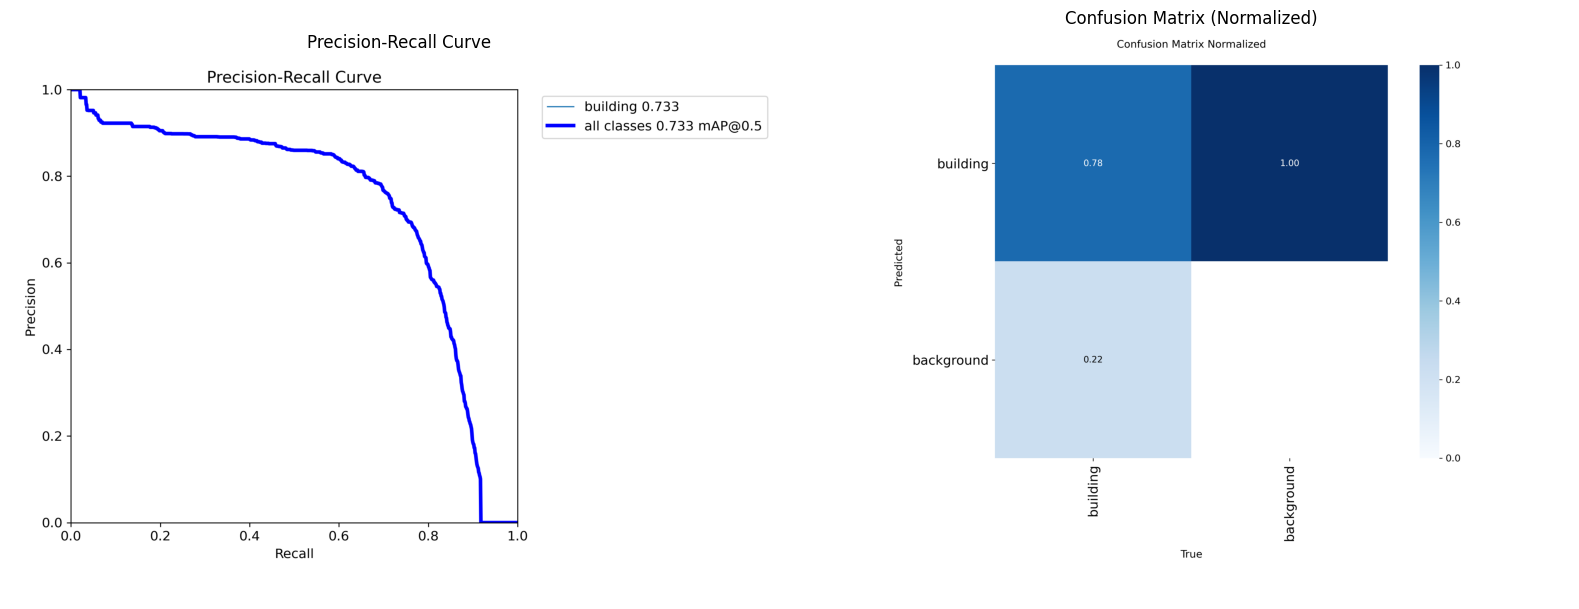

In [58]:
# Step 5: Display PR curve and Confusion Matrix side by side
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.imshow(mpimg.imread('/content/runs/spacenet_buildings/BoxPR_curve.png'))
ax1.set_title('Precision-Recall Curve')
ax1.axis('off')

ax2.imshow(mpimg.imread('/content/runs/spacenet_buildings/confusion_matrix_normalized.png'))
ax2.set_title('Confusion Matrix (Normalized)')
ax2.axis('off')

plt.tight_layout()
plt.show()

Total train images: 1148
Images with buildings: 621
Sampling 10 images
Mean Absolute Error in count: 3.20


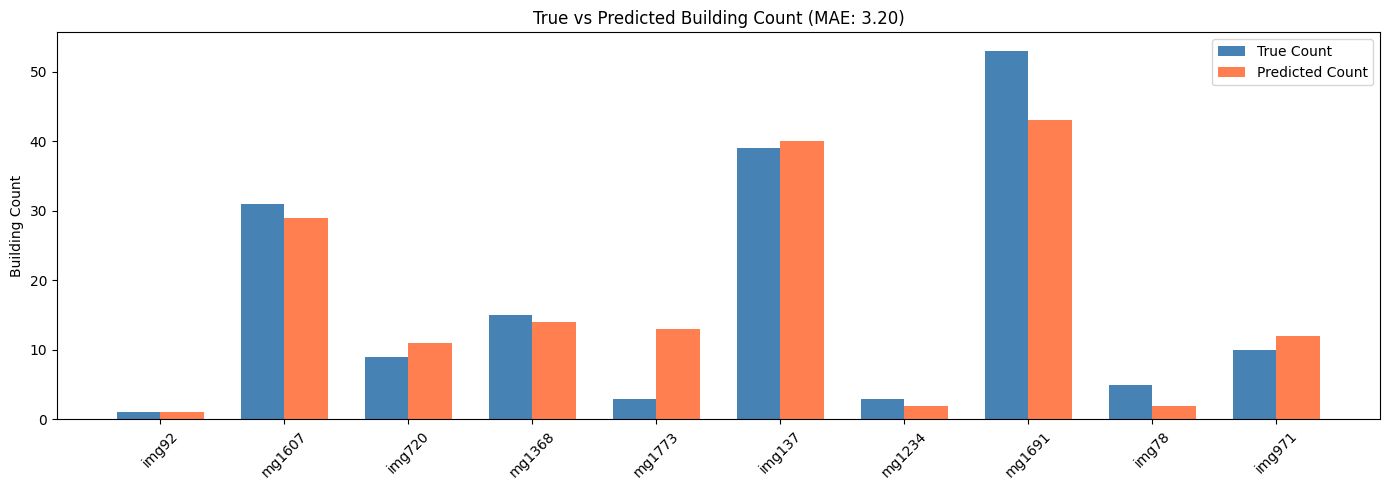

In [59]:
# Step 6.1: Reusable detection function tested on images with true vs predicted count bar chart
import cv2, time, random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

model = YOLO('/content/runs/spacenet_buildings/weights/best.pt')

def detect_buildings(img_path, model):
    start = time.time()
    results = model(img_path, verbose=False)
    elapsed = (time.time() - start) * 1000
    boxes = results[0].boxes
    count = len(boxes)
    avg_conf = float(boxes.conf.mean()) if count > 0 else 0.0
    return count, avg_conf, elapsed, results[0]

img_dir = Path('/content/spacenet/train/images')
lbl_dir = Path('/content/spacenet/train/labels')

all_imgs = sorted(img_dir.glob('*.jpg'))
imgs_with_buildings = [p for p in all_imgs
                       if (lbl_dir / (p.stem + '.txt')).exists()
                       and (lbl_dir / (p.stem + '.txt')).stat().st_size > 0]

print(f"Total train images: {len(all_imgs)}")
print(f"Images with buildings: {len(imgs_with_buildings)}")

n = min(10, len(imgs_with_buildings))
sample = random.sample(imgs_with_buildings, n)
print(f"Sampling {n} images")

true_counts, pred_counts, img_names = [], [], []
for img_path in sample:
    lbl_path = lbl_dir / (img_path.stem + '.txt')
    true_count = sum(1 for line in open(lbl_path) if line.strip())
    pred_count, _, _, _ = detect_buildings(str(img_path), model)
    true_counts.append(true_count)
    pred_counts.append(pred_count)
    img_names.append(img_path.stem)

mae = np.mean(np.abs(np.array(true_counts) - np.array(pred_counts)))
print(f"Mean Absolute Error in count: {mae:.2f}")

x = np.arange(len(img_names))
width = 0.35
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, true_counts, width, label='True Count', color='steelblue')
ax.bar(x + width/2, pred_counts, width, label='Predicted Count', color='coral')
ax.set_xticks(x)
ax.set_xticklabels([n[-6:] for n in img_names], rotation=45)
ax.set_title(f'True vs Predicted Building Count (MAE: {mae:.2f})')
ax.set_ylabel('Building Count')
ax.legend()
plt.tight_layout()
plt.show()

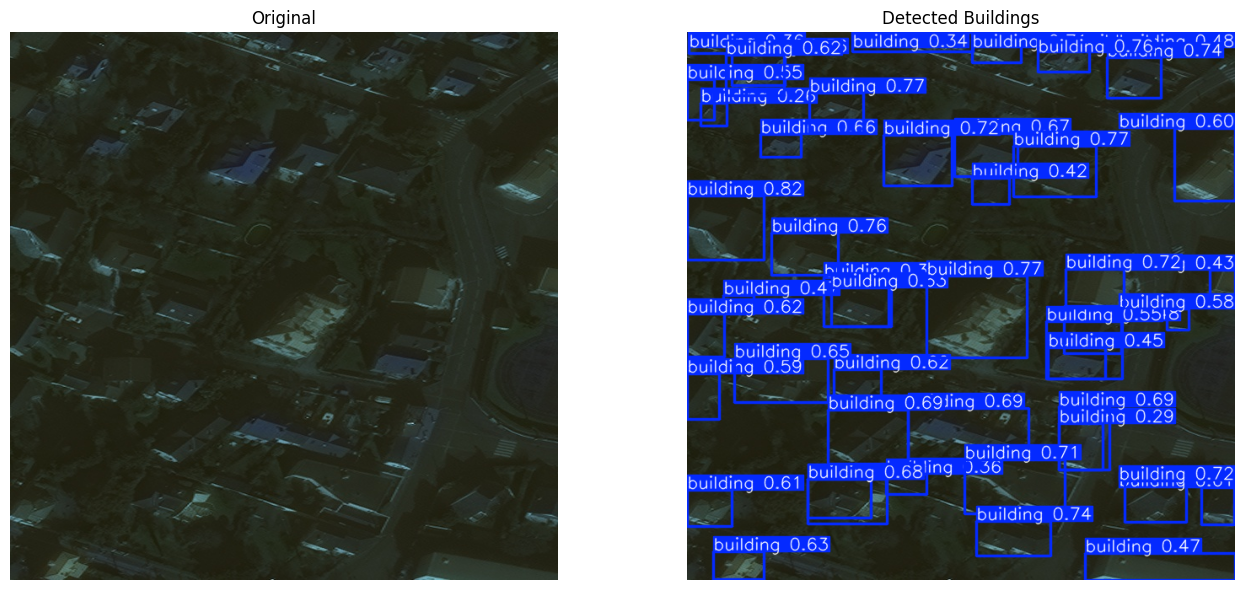

Image: img681.jpg
  Buildings detected : 48
  Avg confidence     : 0.58
  Processing time    : 61.3 ms



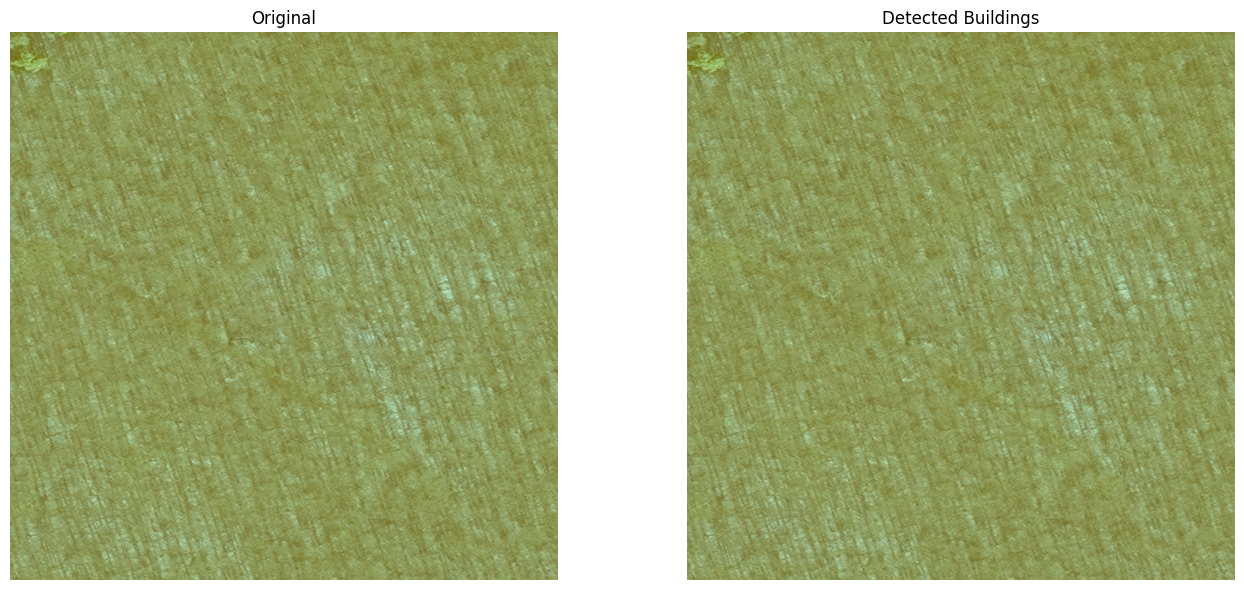

Image: img1114.jpg
  Buildings detected : 0
  Avg confidence     : 0.00
  Processing time    : 22.8 ms



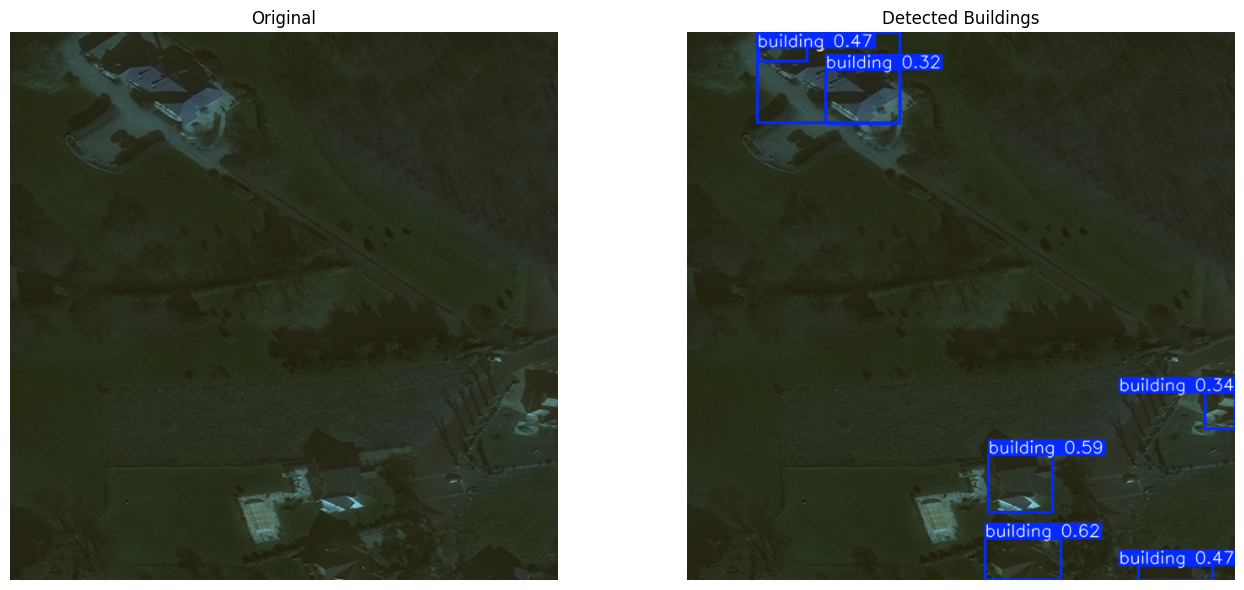

Image: img926.jpg
  Buildings detected : 7
  Avg confidence     : 0.45
  Processing time    : 23.6 ms



In [60]:
# Step 6.2: Full end-to-end pipeline - original vs annotated side by side for 3 images
import cv2
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
test_imgs = sorted(Path('/content/spacenet/images/val').glob('*.jpg'))
sample = random.sample(test_imgs, 3)


model = YOLO('/content/runs/spacenet_buildings/weights/best.pt')

def full_pipeline(img_path, model):
    start = time.time()
    results = model(str(img_path), verbose=False)
    elapsed = (time.time() - start) * 1000
    boxes = results[0].boxes
    count = len(boxes)
    avg_conf = float(boxes.conf.mean()) if count > 0 else 0.0
    annotated = results[0].plot()
    annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    original = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    return original, annotated, count, avg_conf, elapsed

test_imgs = sorted(Path('/content/spacenet/images/test').glob('*.jpg'))
sample = random.sample(test_imgs, 3)

for img_path in sample:
    original, annotated, count, avg_conf, elapsed = full_pipeline(img_path, model)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    ax1.imshow(original)
    ax1.set_title('Original')
    ax1.axis('off')
    ax2.imshow(annotated)
    ax2.set_title('Detected Buildings')
    ax2.axis('off')
    plt.tight_layout()
    plt.show()


    print(f"Image: {img_path.name}")
    print(f"  Buildings detected : {count}")
    print(f"  Avg confidence     : {avg_conf:.2f}")
    print(f"  Processing time    : {elapsed:.1f} ms\n")